IMPORTING LIBRARIES

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [67]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [68]:
type(x_train)

numpy.ndarray

In [69]:
x_train.shape #numpy array

(60000, 28, 28)

In [70]:
y_train.shape

(60000,)

In [71]:
x_test.shape

(10000, 28, 28)

In [72]:
y_test.shape

(10000,)

In [73]:
#grayscale images

Training images = 60,000
Test data = 10,000

Grayscale images
Dimesion - 28 x 28


In [74]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [75]:
print(x_train[10].shape)

(28, 28)


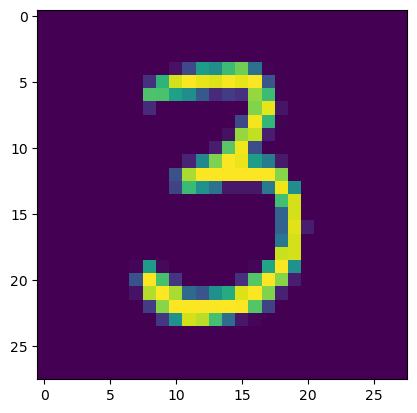

3


In [76]:
plt.imshow(x_train[50])
plt.show()
print(y_train[50])

In [77]:
#normalisation of data
x_train = x_train/255
x_test = x_test/255


In [78]:
print(x_train_new[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

NEURAL NETWORKS

In [79]:
inpu_t = keras.Input(shape=(28, 28))  
x = keras.layers.Flatten()(inpu_t) 
x = keras.layers.Dense(50, activation='relu')(x)  
x = keras.layers.Dense(50, activation='relu')(x) 
outputlayer = keras.layers.Dense(10, activation='sigmoid')(x)  

model = keras.Model(inputs=inpu_t, outputs=outputlayer)


In [80]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [81]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3101 - accuracy: 0.9104
Epoch 2/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1465 - accuracy: 0.9557
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1081 - accuracy: 0.9664
Epoch 4/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0882 - accuracy: 0.9727
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0729 - accuracy: 0.9771
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0623 - accuracy: 0.9803
Epoch 7/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0548 - accuracy: 0.9823
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0470 - accuracy: 0.9844
Epoch 9/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0429 - accuracy: 0.9865
Epoch 10/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.036

In [82]:
loss,accuracy = model.evaluate(x_test,y_test)
print(accuracy)

313/313 [==============================] - 1s 2ms/step - loss: 0.0939 - accuracy: 0.9736
0.9735999703407288


tRAINING DATA ACCURACY - 98.76
TEST DATA ACCURACY - 97.36

CUSTOM PREDICTION

In [83]:
check = model.predict(x_test)
print(check.shape)

313/313 [==============================] - 1s 2ms/step
(10000, 10)


In [86]:
check_first_image = np.argmax(check[50])
print(check_first_image)

6


In [88]:
check_labels = [np.argmax(i) for i in check]

CONFUSION MATRIX

In [89]:
from tensorflow.math import confusion_matrix

In [90]:
cmx = confusion_matrix(y_test,check_labels)

In [91]:
print(cmx)

tf.Tensor(
[[ 966    1    2    2    2    1    3    1    1    1]
 [   0 1121    2    3    1    2    2    3    1    0]
 [   5    2 1006    3    2    1    2    7    4    0]
 [   0    0   10  974    0    9    0    6    3    8]
 [   2    0    3    1  962    3    2    0    0    9]
 [   2    2    0    9    1  868    5    0    4    1]
 [   5    3    5    2    6    8  928    0    1    0]
 [   0    3   13    3    2    0    0  999    2    6]
 [   1    1    5    3    5    9    1    5  942    2]
 [   1    2    1    7   12    8    0    6    2  970]], shape=(10, 10), dtype=int32)


In [92]:
from keras.models import load_model

In [93]:
model.save('pradeep.h5')

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
